# Visualization Engine V2 Research Workbench & Interactive Debugger

This notebook demonstrates the passive Visualization Engine V2 architecture, including:
1. Loading historical Forex data.
2. Computing indicators and running analytical engines (`MarketStructureEngine`, `SupplyDemandEngine`).
3. Generating structured visual instructions in CSV format via `ChartAnnotationEngine` and `DrawInstructionWriter`.
4. Rendering identical, point-in-time correct, interactive debugging layers using Matplotlib.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

# Ensure repo root is on PATH
sys.path.append(os.path.abspath(".."))

from Collecting_Data.indicators import IndicatorEngine
from Market_Data_Pipeline.structure_engine import MarketStructureEngine
from Market_Data_Pipeline.supply_demand_engine import SupplyDemandEngine
from Market_Data_Pipeline.state_engine import MarketStateEngine
from Market_Data_Pipeline.structure_graph import MarketStructureGraph
from Visualization.chart_annotator import ChartAnnotationEngine
from Visualization.debug_config import DebugConfig

## 1. Create Mock Historical OHLC Data

In [2]:
n_bars = 200
np.random.seed(42)
prices = 1.1000 + np.cumsum(np.random.normal(0, 0.001, n_bars))
dates = pd.date_range(start="2026-01-01", periods=n_bars, freq="5min")

df_raw = pd.DataFrame({
    "Datetime": dates,
    "Open": prices,
    "High": prices + 0.0005,
    "Low": prices - 0.0005,
    "Close": prices + np.random.normal(0, 0.0001, n_bars),
    "TickVolume": [100]*n_bars,
    "Spread": [1]*n_bars
})
df_raw["High"] = df_raw[["Open", "Close"]].max(axis=1) + 0.0008
df_raw["Low"] = df_raw[["Open", "Close"]].min(axis=1) - 0.0008

print(df_raw.head())

             Datetime      Open      High       Low     Close  TickVolume  \
0 2026-01-01 00:00:00  1.100497  1.101332  1.099697  1.100532         100   
1 2026-01-01 00:05:00  1.100358  1.101215  1.099558  1.100415         100   
2 2026-01-01 00:10:00  1.101006  1.101914  1.100206  1.101114         100   
3 2026-01-01 00:15:00  1.102529  1.103435  1.101729  1.102635         100   
4 2026-01-01 00:20:00  1.102295  1.103095  1.101357  1.102157         100   

   Spread  
0       1  
1       1  
2       1  
3       1  
4       1  


## 2. Process Analytical and Structural Engines

In [3]:
ind_engine = IndicatorEngine(ema_periods=[50, 600], slope_period=32)
df_ind = ind_engine.calculate(df_raw)

struct_engine = MarketStructureEngine(lookback=3)
df_struct = struct_engine.process(df_ind)

sd_engine = SupplyDemandEngine(atr_period=14, impulse_threshold=1.5)
df_sd = sd_engine.process(df_struct)

state_engine = MarketStateEngine()

last_row = df_sd.iloc[-1]
graph = MarketStructureGraph(
    symbol="EURUSD",
    timeframe="M5",
    timestamp=last_row["Datetime"],
    swing_highs=[s for s in struct_engine.swings if s.level_type == 'SwingHigh'],
    swing_lows=[s for s in struct_engine.swings if s.level_type == 'SwingLow'],
    protected_high=struct_engine.protected_high,
    protected_low=struct_engine.protected_low,
    bos=list(struct_engine.bos_list),
    choch=list(struct_engine.choch_list),
    supply_zones=[z for z in sd_engine.zones if z.type == 'Supply'],
    demand_zones=[z for z in sd_engine.zones if z.type == 'Demand'],
    trend_direction="Bull" if last_row.get("trend", 0) == 1 else ("Bear" if last_row.get("trend", 0) == -1 else "Neutral"),
    atr=float(last_row.get("atr_14", 0.001)),
    volatility=float(last_row.get("atr_14", 0.001) * 10000.0)
)

state_ctx = state_engine.evaluate(graph)
print(f"Evaluated State Context: {state_ctx}")

Input DataFrame has fewer rows (200) than warmup requirement (632). Indicators may not be fully warmed up.


Evaluated State Context: StateContext(regime='Expansion', trend_direction='Bear', volatility_regime='High', confidence_score=0.75, ema_slope=0.0, ema_distance_atr=0.0, atr=0.0018128027630710311, timestamp=Timestamp('2026-01-01 16:35:00'))


## 3. Generate Visual Drawing CSV Instructions via ChartAnnotationEngine

In [4]:
config = DebugConfig()
annotator = ChartAnnotationEngine(config=config)

trade_plan = {
    "entry_price": 1.1000,
    "sl_price": 1.0950,
    "tp_price": 1.1100,
    "invalidation_level": 1.0945
}

decision = {
    "direction": 1,
    "accepted": True,
    "reason": "High-Risk Bullish structural setup",
    "signal_type": "High-Risk",
    "strategy": "MM"
}

ml_output = {
    "quality_score": 0.88,
    "break_prob": 0.15,
    "range_prob": 0.20,
    "trend_prob": 0.80,
    "confidence": 0.90
}

annotator.render(
    symbol="EURUSD",
    structure_graph=graph,
    state_context=state_ctx,
    trade_plan=trade_plan,
    decision=decision,
    ml_output=ml_output
)

print("Visual CSV instructions successfully written to output/Files/")

Visual CSV instructions successfully written to output/Files/


## 4. Render Matplotlib Overlays for Interactive Debugging

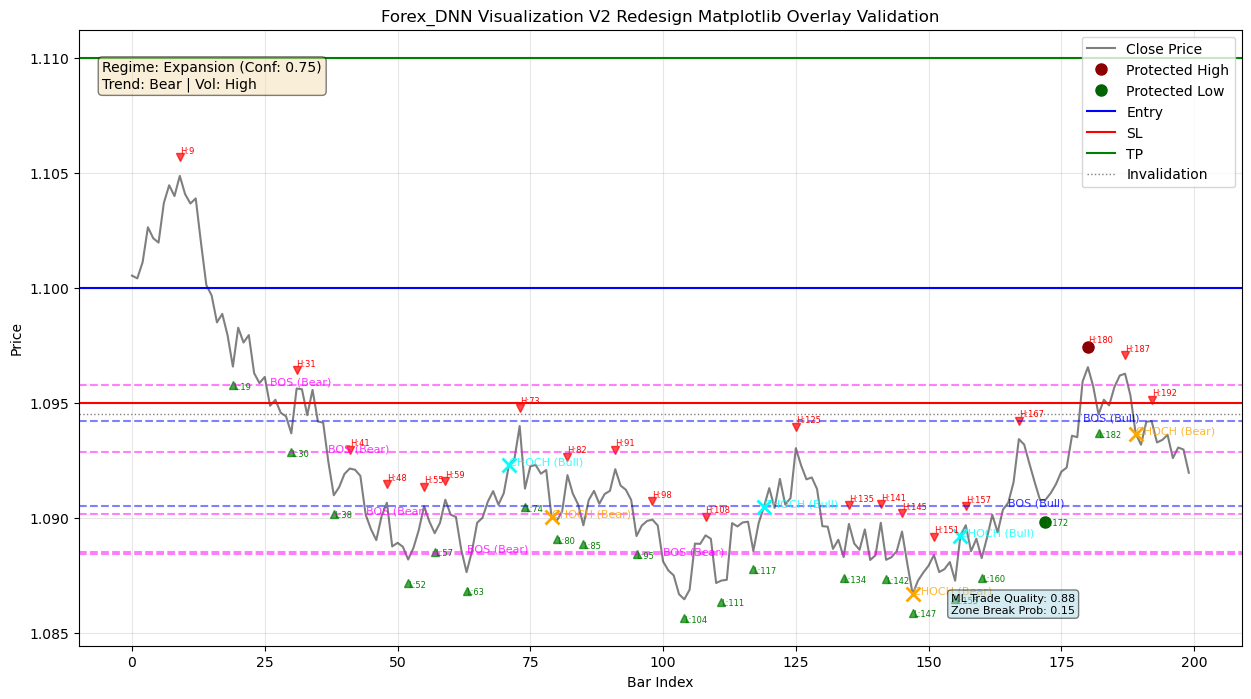

In [5]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(df_sd.index, df_sd["Close"], label="Close Price", color="black", alpha=0.5)

annotator.annotate_matplotlib(
    ax=ax,
    msg=graph,
    state_ctx=state_ctx,
    trade_levels=trade_plan,
    signal_info=decision,
    ml_info=ml_output
)

plt.title("Forex_DNN Visualization V2 Redesign Matplotlib Overlay Validation")
plt.xlabel("Bar Index")
plt.ylabel("Price")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()